# SIR Model with Ridge Regression
## Epidemic Dynamics Modeling for COVID-19

### The SIR Framework

The SIR model divides a fixed population N into three compartments:

| Compartment | Symbol | Meaning |
|-------------|--------|---------|
| Susceptible | S | Not yet infected but can be |
| Infected | I | Currently infected |
| Recovered | R | Recovered or deceased (immune) |

**Governing differential equations:**

- dS/dt = −β·S·I / N
- dI/dt = β·S·I / N − γ·I
- dR/dt = γ·I

Where **β** is the transmission rate and **γ** is the recovery/removal rate.

**Novelty:** We couple the SIR model with Ridge Regression to predict β and γ for the next 20 days using the last 15 days as the sliding window.


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge


## 1. Load & Aggregate Global COVID Data

In [6]:
# Load raw data
raw = pd.read_csv("/content/covid_19_data.csv")

# Drop columns safely
raw = raw.drop(columns=[
    "Province/State", "Country/Region", "Last Update"
], errors='ignore')

# Convert correct date column
raw['ObservationDate'] = pd.to_datetime(raw['ObservationDate'], errors='coerce', dayfirst=True)

# Aggregate daily totals
daily_agg = (
    raw.groupby("ObservationDate")
       .agg(Confirmed=("Confirmed", "sum"),
            Deaths=("Deaths", "sum"),
            Recovered=("Recovered", "sum"),
            SNo=("SNo", list))
       .reset_index()
)

daily_agg.head()

,ObservationDate,Confirmed,Deaths,Recovered,SNo
0,2020-01-22,557.0,17.0,30.0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,2020-01-23,1097.0,34.0,60.0,"[41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 5..."
2,2020-01-24,941.0,26.0,39.0,"[89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 1..."
3,2020-01-25,1437.0,42.0,42.0,"[132, 133, 134, 135, 136, 137, 138, 139, 140, ..."
4,2020-01-26,2118.0,56.0,56.0,"[178, 179, 180, 181, 182, 183, 184, 185, 186, ..."


In [7]:
# Sort by SNo and compute cumulative totals
daily_agg = daily_agg.sort_values('SNo')
daily_agg = daily_agg.drop(columns=['SNo'])

data = pd.DataFrame()
data['Confirmed'] = daily_agg['Confirmed'].cumsum().values
data['Deaths']    = daily_agg['Deaths'].cumsum().values
data['Recovered'] = daily_agg['Recovered'].cumsum().values
data = data.reset_index(drop=True)

test_data = data.tail(50)
print("Full dataset rows:", len(data))
data.head()


Full dataset rows: 494


,Confirmed,Deaths,Recovered
0,557.0,17.0,30.0
1,1654.0,51.0,90.0
2,2595.0,77.0,129.0
3,4032.0,119.0,171.0
4,6150.0,175.0,227.0


In [8]:
test_data


,Confirmed,Deaths,Recovered
444,1.868755e+10,465306391.0,1.095009e+10
445,1.882360e+10,468243315.0,1.102755e+10
446,1.896026e+10,471189547.0,1.110541e+10
447,1.909770e+10,474149121.0,1.118376e+10
448,1.923596e+10,477122246.0,1.126255e+10
449,1.937504e+10,480108584.0,1.134178e+10
450,1.951497e+10,483107759.0,1.142153e+10
451,1.965569e+10,486118957.0,1.150178e+10
452,1.979710e+10,489138780.0,1.158262e+10
453,1.993919e+10,492169112.0,1.166400e+10


## 2. Derive SIR Compartments

In [9]:
POPULATION = 143_932_377_600  # global population proxy

X_conf  = data['Confirmed'].to_numpy(dtype=float)   # cumulative confirmed
recovered_arr = data['Recovered'].to_numpy(dtype=float)
death_arr     = data['Deaths'].to_numpy(dtype=float)

# Active infected: I = Confirmed - Recovered - Deaths
I = X_conf - recovered_arr - death_arr
# Removed: R = Recovered + Deaths
R_sir = recovered_arr + death_arr
# Population array
N = np.full(len(I), POPULATION, dtype=float)
# Susceptible
S = N - I - R_sir


## 3. Compute Daily β and γ

In [10]:
# γ: daily recovery/removal rate
gamma_arr = (R_sir[1:] - R_sir[:-1]) / I[:-1]

# β: daily transmission rate
beta_arr = (
    N[:-1] * (I[1:] - I[:-1] + R_sir[1:] - R_sir[:-1])
    / (I[:-1] * (N[:-1] - I[:-1] - R_sir[:-1]))
)

# Basic reproduction number R0
R0 = beta_arr / gamma_arr


## 4. Prepare Sliding-Window Dataset for Ridge Regression

In [11]:
def make_windowed_dataset(series: np.ndarray, window: int):
    """Create (X, y) pairs from a 1-D time series using a sliding window."""
    X_w = np.array([series[i: i + window] for i in range(len(series) - window)])
    y_w = series[window:]
    return X_w, y_w

WINDOW = 15   # use last 15 days to predict next day
X_beta,  y_beta  = make_windowed_dataset(beta_arr,  WINDOW)
X_gamma, y_gamma = make_windowed_dataset(gamma_arr, WINDOW)


## 5. Fit Ridge Regression Models

In [12]:
# Ridge regressors for β and γ (no intercept — purely linear combination of lags)
ridge_beta  = Ridge(alpha=0.1, fit_intercept=False)
ridge_gamma = Ridge(alpha=0.1, fit_intercept=False)

ridge_beta.fit(X_beta,   y_beta)
ridge_gamma.fit(X_gamma, y_gamma)

beta_fitted  = ridge_beta.predict(X_beta)
gamma_fitted = ridge_beta.predict(X_gamma)


## 6. 20-Day Forward Simulation

In [13]:
FORECAST_DAYS = 20

# Initialise SIR forecasts from the last observed values
S_pred = [S[-1]]
I_pred = [I[-1]]
R_pred = [R_sir[-1]]

# Sliding windows initialised from recent history
window_beta  = list(beta_arr[-WINDOW:])
window_gamma = list(gamma_arr[-WINDOW:])

for _ in range(FORECAST_DAYS):
    # Pad window if needed (shouldn't be after first iteration)
    pad_b = (window_beta[-WINDOW:]  + [0] * WINDOW)[:WINDOW]
    pad_g = (window_gamma[-WINDOW:] + [0] * WINDOW)[:WINDOW]

    next_beta  = ridge_beta.predict([pad_b])[0]
    next_gamma = ridge_gamma.predict([pad_g])[0]

    # Clip to non-negative
    next_beta  = max(next_beta,  0)
    next_gamma = max(next_gamma, 0)

    window_beta.append(next_beta)
    window_gamma.append(next_gamma)

    # SIR update equations (discrete)
    dS = -next_beta * S_pred[-1] * I_pred[-1] / N[-1]
    dI =  next_beta * S_pred[-1] * I_pred[-1] / N[-1] - next_gamma * I_pred[-1]
    dR =  next_gamma * I_pred[-1]

    S_pred.append(S_pred[-1] + dS)
    I_pred.append(I_pred[-1] + dI)
    R_pred.append(R_pred[-1] + dR)

print(f"Day-1 Forecast  =>  Infected: {int(I_pred[1]):,}   Removed: {int(R_pred[1]):,}")
print(f"Expected total confirmed: {int(I_pred[1] + R_pred[1]):,}")


Day-1 Forecast  =>  Infected: 10,234,841,697   Removed: 16,182,573,718
Expected total confirmed: 26,417,415,416


## 7. Visualisation

  COVID-19 Infected Cases (Day 1 Forecast) :  10,234,841,697
  Recovered + Deaths (Day 1 Forecast)      :  16,182,573,718
  Expected Confirmed (Infected + Removed)  :  26,417,415,416


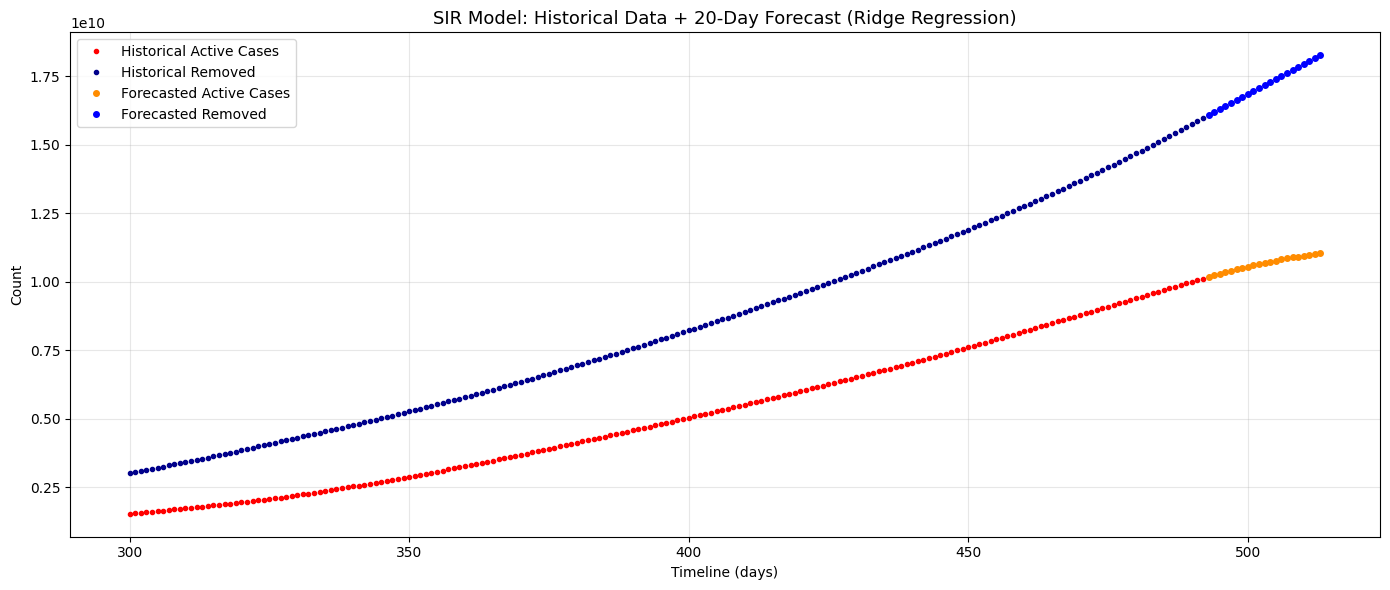

In [14]:
def plot_sir_forecast():
    HISTORY_START = 300   # show history from this day onward

    hist_range    = range(HISTORY_START, len(I))
    forecast_range = range(len(I) - 1, len(I) - 1 + len(I_pred))

    plt.figure(figsize=(14, 6))

    # History
    plt.plot(hist_range, I[HISTORY_START:],       'o', color='red',     label='Historical Active Cases',  markersize=3)
    plt.plot(hist_range, R_sir[HISTORY_START:],   'o', color='darkblue',label='Historical Removed',       markersize=3)

    # Forecast
    plt.plot(forecast_range, I_pred, 'o', color='darkorange', label='Forecasted Active Cases', markersize=4)
    plt.plot(forecast_range, R_pred, 'o', color='blue',       label='Forecasted Removed',      markersize=4)

    plt.title('SIR Model: Historical Data + 20-Day Forecast (Ridge Regression)', fontsize=13)
    plt.xlabel('Timeline (days)')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("=" * 55)
print(f"  COVID-19 Infected Cases (Day 1 Forecast) : {int(I_pred[1]):>15,}")
print(f"  Recovered + Deaths (Day 1 Forecast)      : {int(R_pred[1]):>15,}")
print(f"  Expected Confirmed (Infected + Removed)  : {int(I_pred[1] + R_pred[1]):>15,}")
print("=" * 55)

plot_sir_forecast()
